# End-to-End Diabetes Prediction: Data Visualization 📈
This notebook performs exploratory data analysis (EDA) and generates beautiful, high-quality visualizations for the Pima Indians Diabetes dataset using **Seaborn** and **Matplotlib**. 


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters in one step
plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="muted")
sns.set_context("notebook", font_scale=1.2)


## 1. Data Loading and Preparation
First, we load the dataset and handle the missing values (which are incorrectly encoded as 0 for several biological features in this specific dataset).


In [4]:
# Load the dataset
df = pd.read_csv('diabetes.csv')

# Replace 0 with NaN for features where 0 is physiologically impossible
features_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[features_with_zeros] = df[features_with_zeros].replace(0, np.nan)

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 2. Outcome Distribution (Class Imbalance)
Let's observe the distribution of our target variable `Outcome` to see if there is any class imbalance.


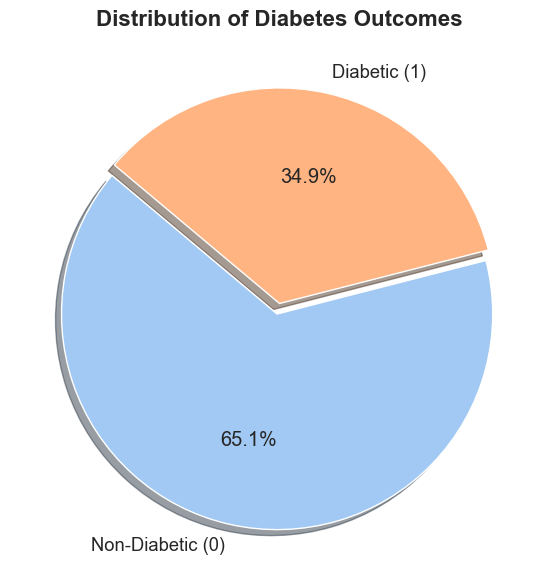

In [5]:
plt.figure(figsize=(7, 7))
labels = ['Non-Diabetic (0)', 'Diabetic (1)']
sizes = df['Outcome'].value_counts().values
colors = sns.color_palette('pastel')[0:2]

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140, explode=(0.05, 0))
plt.title('Distribution of Diabetes Outcomes', fontsize=16, fontweight='bold')
plt.show()


## 3. Correlation Heatmap
Understanding the linear relationships between different features is critical for Machine Learning. A heatmap makes these correlations visually apparent.


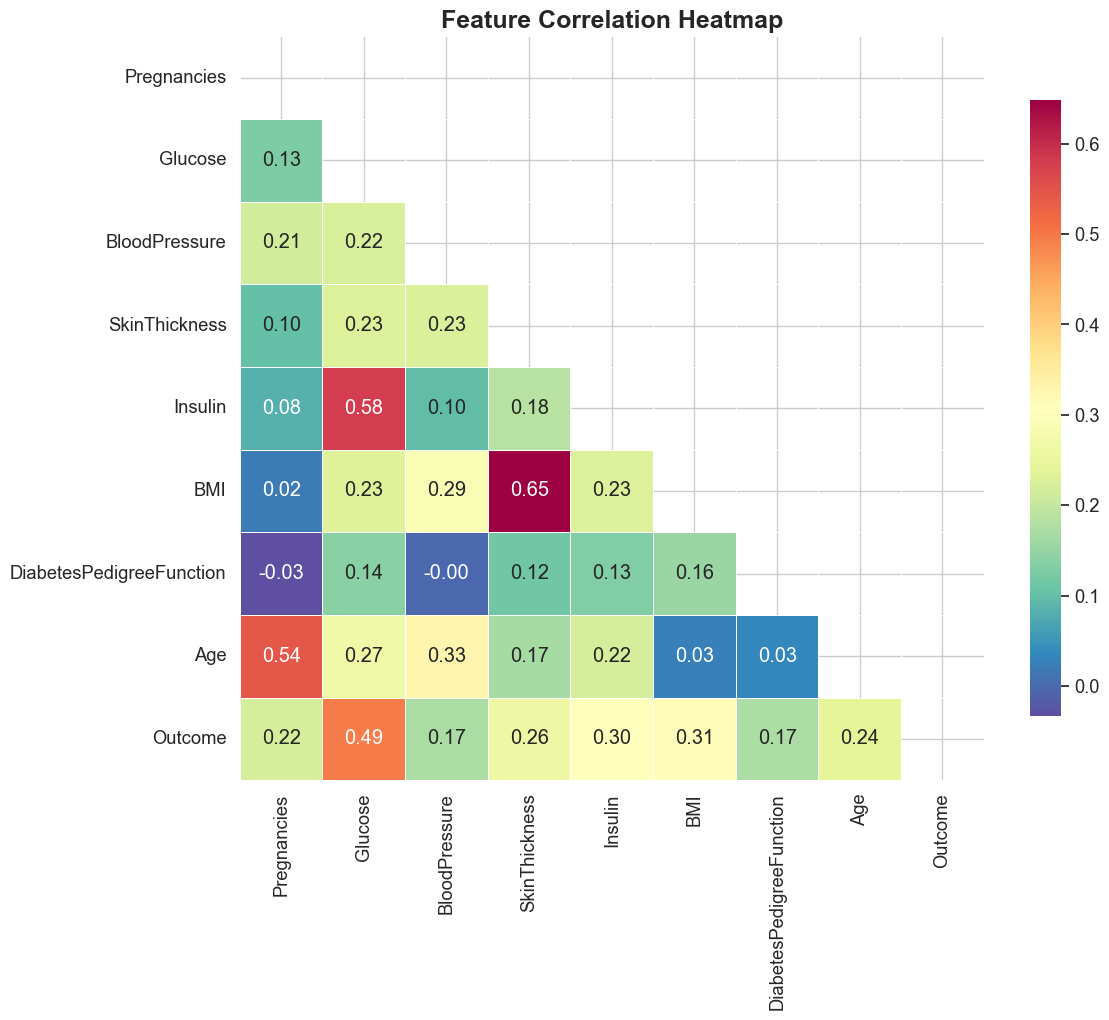

In [6]:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

# Create a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='Spectral_r', square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold')
plt.show()


## 4. Distribution of Medical Features
Visualizing the distribution of each feature, highlighting differences between Diabetic and Non-Diabetic patients using KDE (Kernel Density Estimate) plots overlaying histograms.


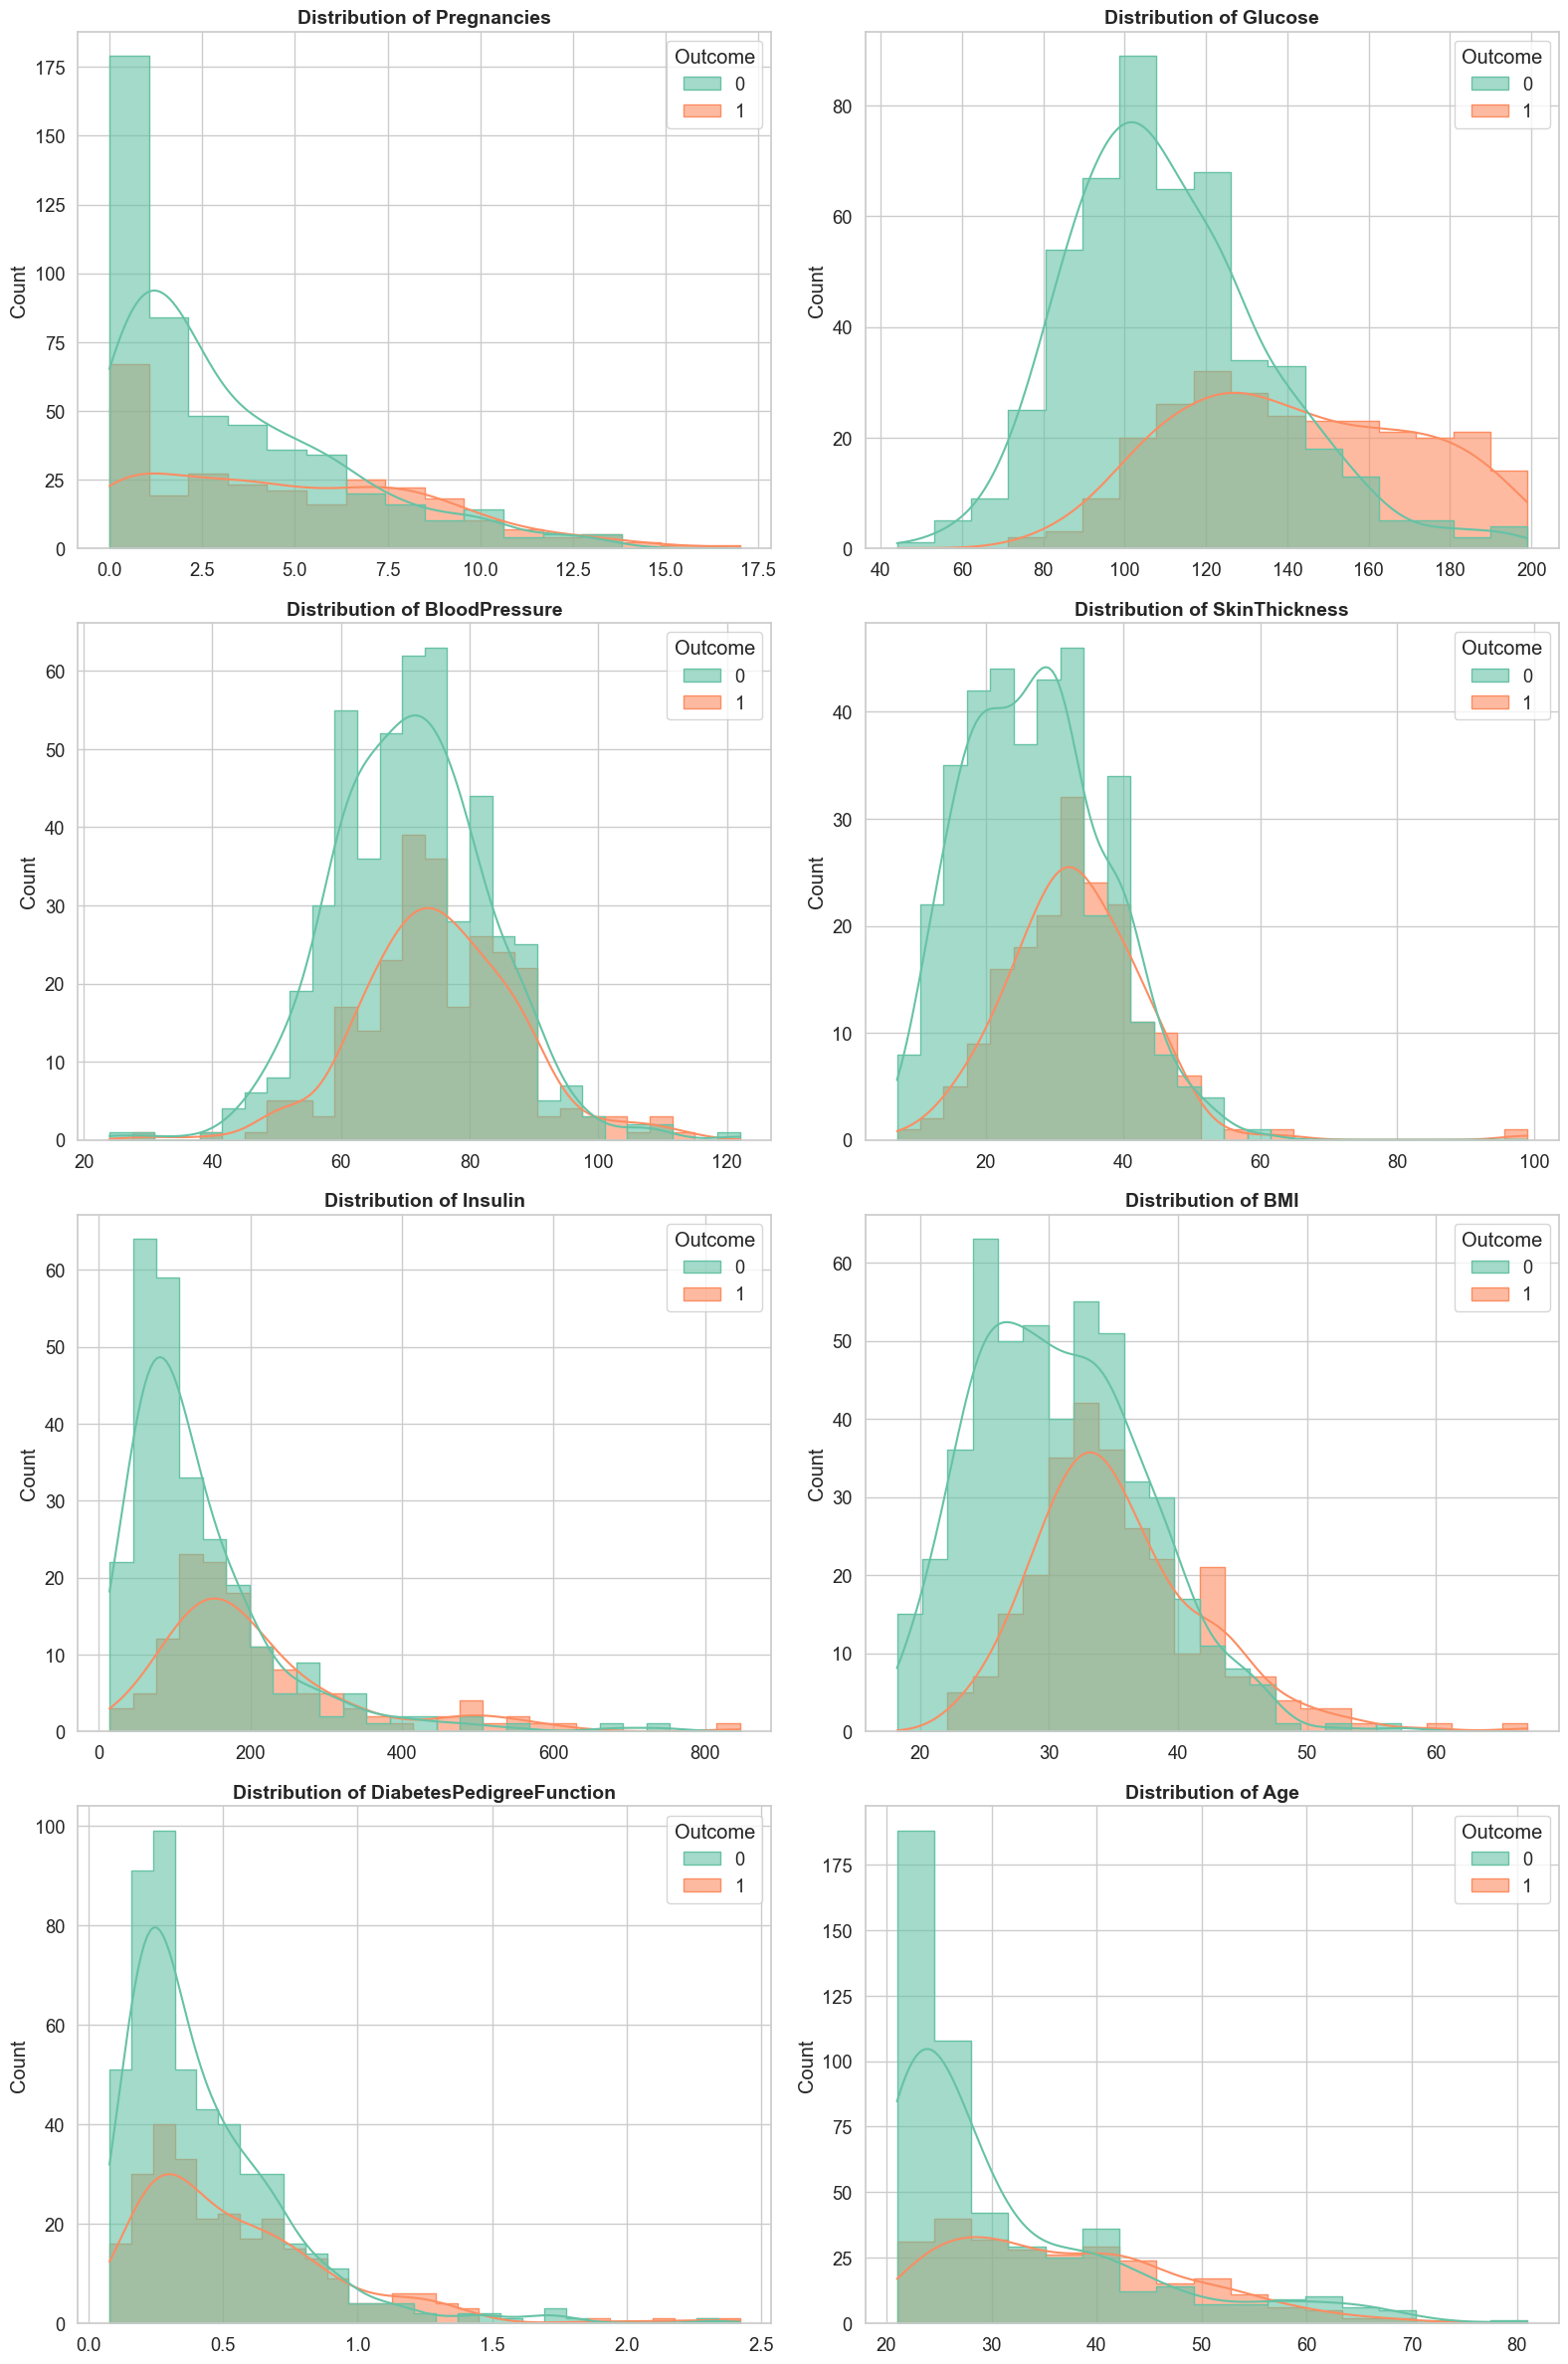

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, ax=axes[i], palette='Set2', alpha=0.6, element="step")
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


## 5. Pairplot of Key Features
A pairplot allows us to see both distribution of single variables and relationships between two variables simultaneously. We will focus on the most linearly correlated features from our heatmap (`Glucose`, `BMI`, `Age`, `Pregnancies`).


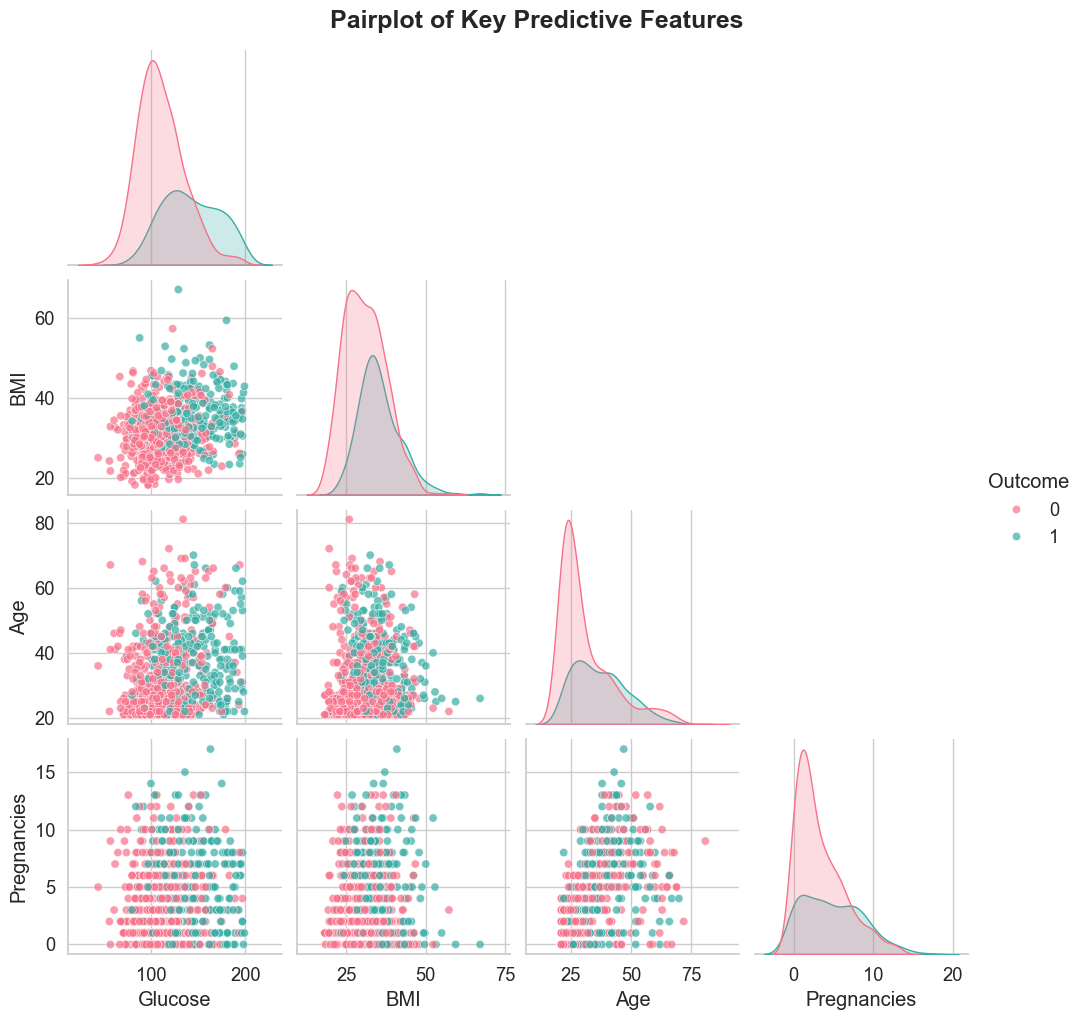

In [9]:
key_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'Outcome']
g = sns.pairplot(df[key_features], hue='Outcome', palette='husl', corner=True, plot_kws={'alpha': 0.7})
g.fig.suptitle('Pairplot of Key Predictive Features', y=1.02, fontsize=18, fontweight='bold')
plt.show()


## 6. Outlier Analysis with Boxplots
Boxplots are excellent for spotting statistical outliers and understanding the spread (quartiles) of the data across both outcomes.


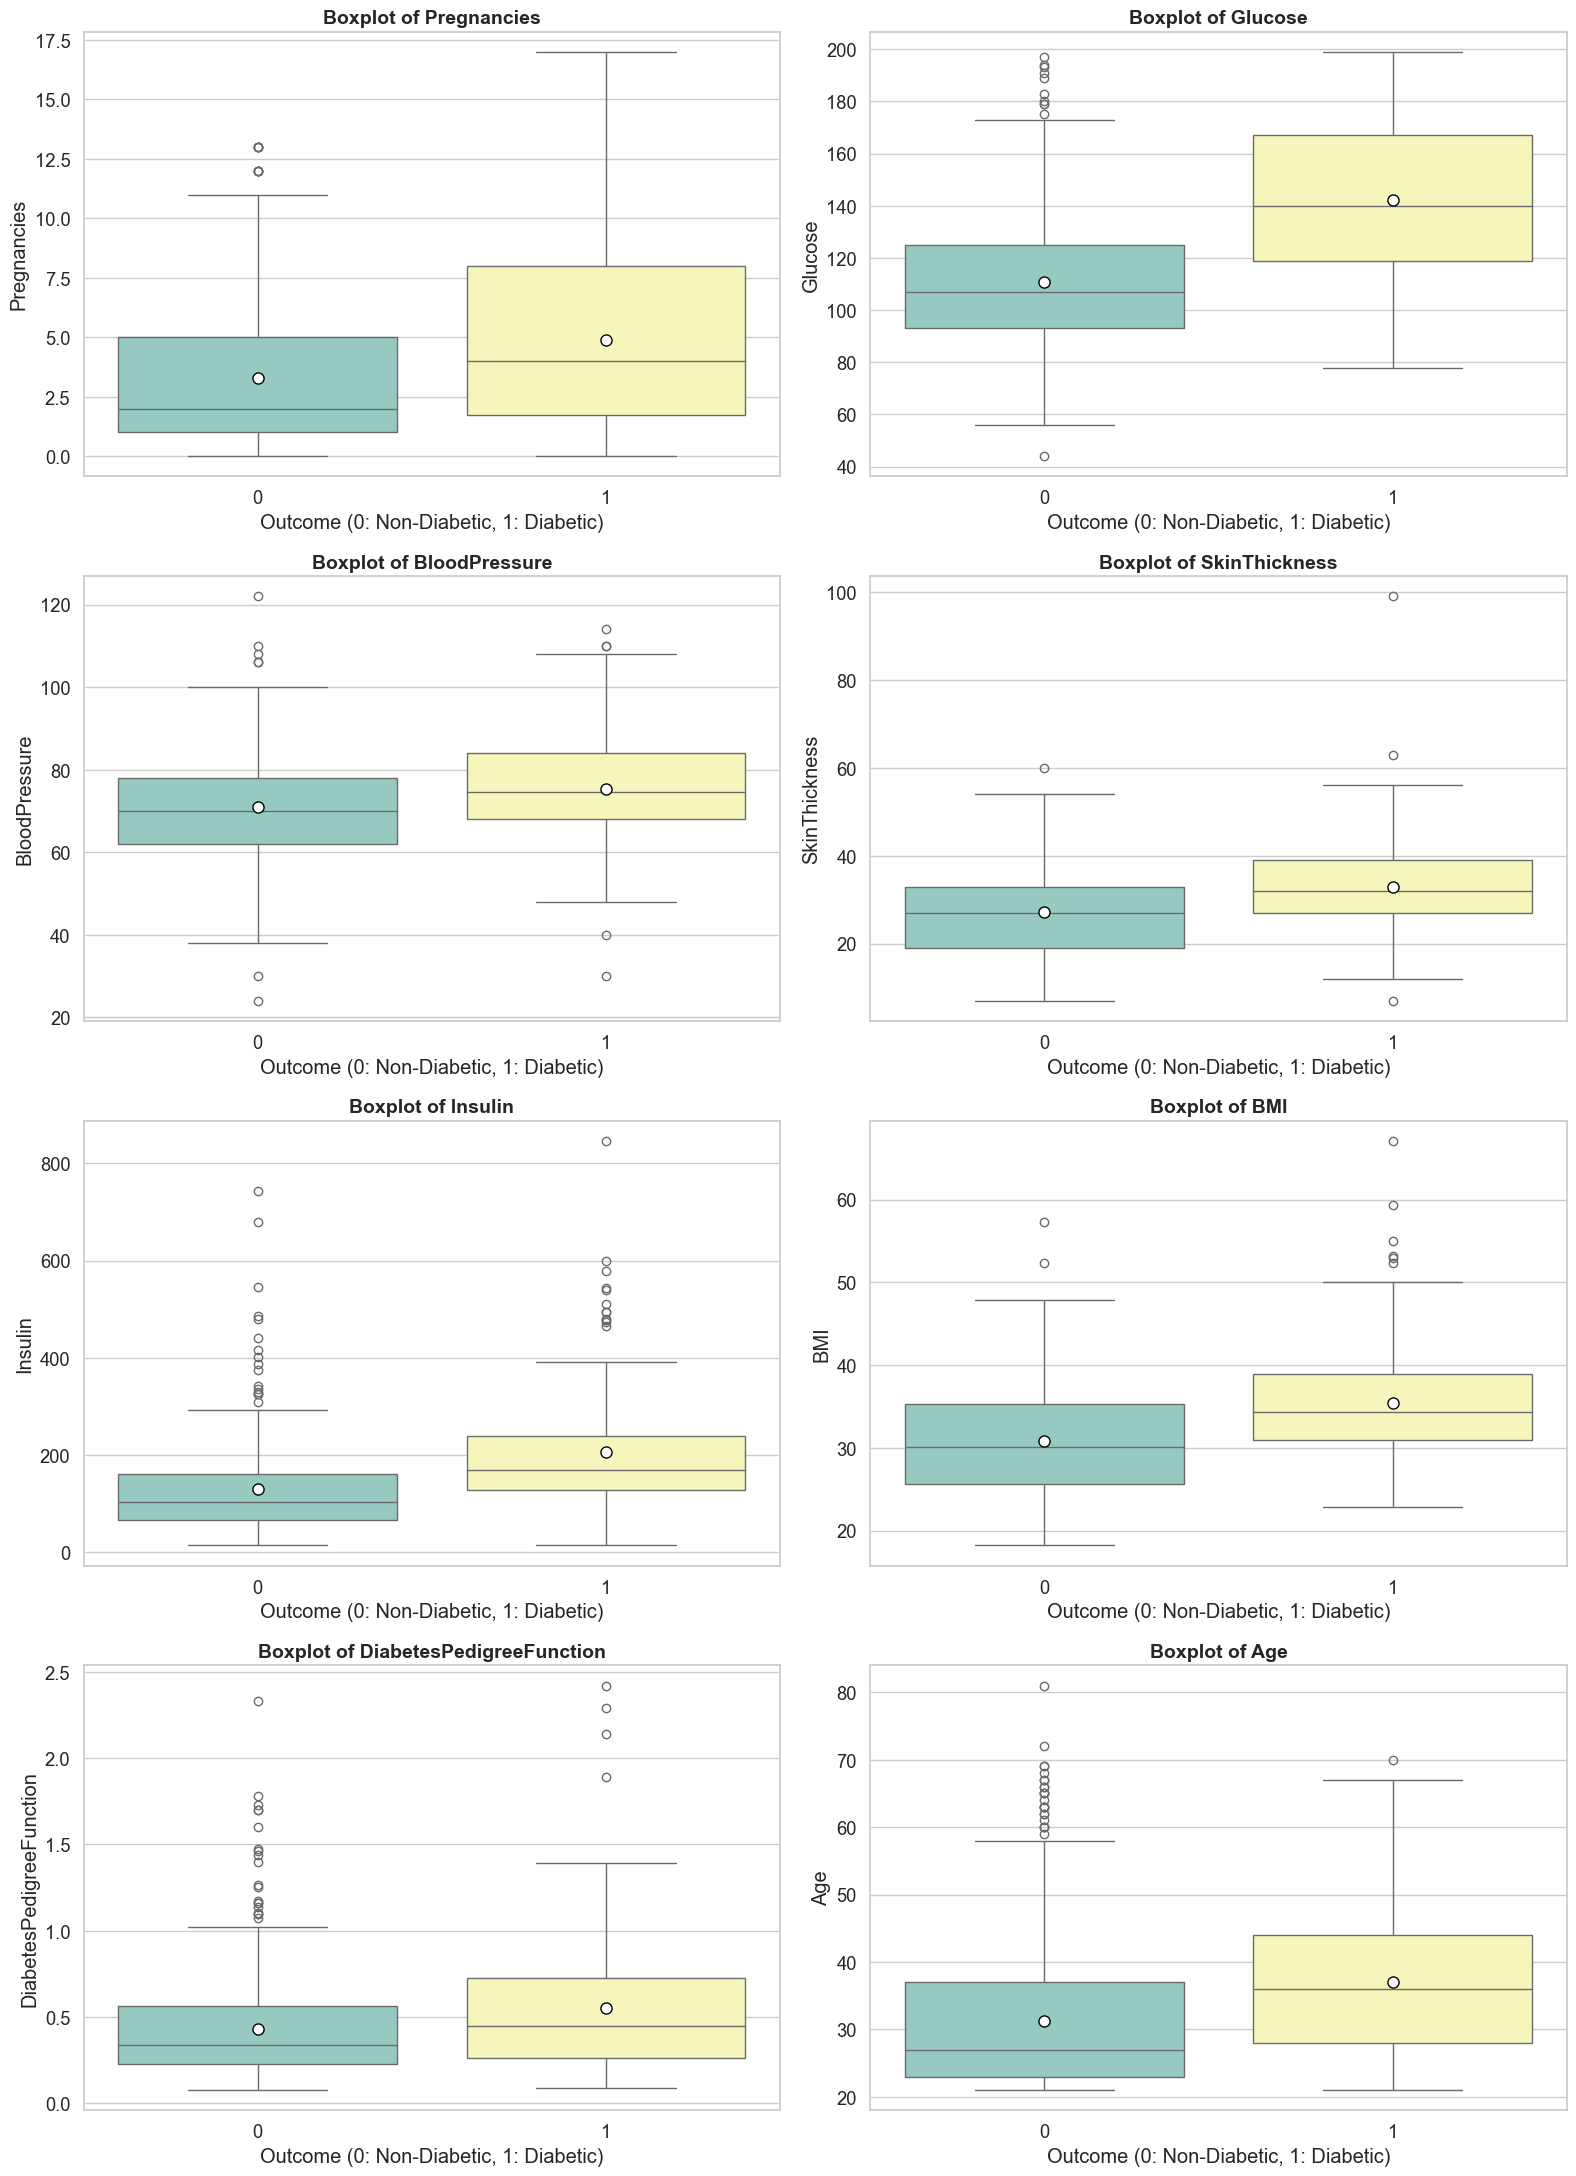

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(data=df, x='Outcome', y=col, ax=axes[i], palette='Set3', showmeans=True, 
                meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
    axes[i].set_title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')

plt.tight_layout()
plt.show()


## Conclusion
These visualizations provide a very clear statistical breakdown of the dataset. For instance, **Glucose** and **BMI** are clear separators between the classes, and the data contains missing values (0s) and outliers that our Random Forest model will learn to handle gracefully.
